# Dataset Preparation for FairChem Training

This notebook demonstrates how to prepare datasets for training machine learning models. We'll convert crystal structure data from CSV format into LMDB format, which is optimized for efficient data loading during training.

## What You'll Learn

1. **Data Conversion**: Convert crystal structure data from CSV to ASE Atoms objects
2. **Dataset Splitting**: Split data into training, validation, and test sets
3. **LMDB Creation**: Generate efficient LMDB databases for training
4. **Data Visualization**: Analyze property distributions.

## Prerequisites

- Basic understanding of crystal structures and materials science
- Familiarity with ASE (Atomic Simulation Environment) and Pymatgen
- Knowledge of machine learning train/validation/test splits

## Input Data Format

The CSV files should contain:
- **cell**: Lattice vectors as 3×3 matrix
- **positions**: Atomic coordinates (fractional)
- **numbers**: Atomic number of each atom 
- **Target properties**: Formation energy, critical temperature, etc.

Let's start by importing the necessary libraries:

In [1]:
from fairchem.core.preprocessing import AtomsToGraphs
from fairchem.core.datasets import LmdbDataset

from pymatgen.core import Lattice, Structure, Molecule
from pymatgen.io.ase import AseAtomsAdaptor

from ase import Atoms

import matplotlib.pyplot as plt
import seaborn as sns

import lmdb
import pickle
from tqdm import tqdm
import torch
import os, shutil
import spglib

import json
import numpy as np
import pandas as pd
import ast

/home/enda/miniconda3/envs/MLFFopt_fairchem/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/enda/miniconda3/envs/MLFFopt_fairchem/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Utility Functions for Data Processing

These utility functions convert CSV string fields into numeric arrays and crystal-structure objects (e.g., pymatgen/ASE). They perform essential preprocessing of raw data before building the training datasets; you can skip this section for now and return to it when needed.

In [2]:
# functions used to convert dataframe row to pymatgen object
def str_to_2d_array(string):
    '''
    The object in panda dataframe is string format.
    Convert to numpy array.
    '''
    if ',' not in string:
        string = string.replace(' ', ',')
    try:
        list_of_lists = ast.literal_eval(string)
        return np.array(list_of_lists)
    except ValueError:
        return None

def symmetrize_structure(structure, symprec=0.001):
    '''
    convert non-premitive to premitive
    '''
    cell = (structure.lattice.matrix, structure.frac_coords, structure.atomic_numbers )
    try:
        lattice, scaled_positions, numbers = spglib.standardize_cell(cell, 
                                                                     to_primitive=True, 
                                                                     no_idealize=False, 
                                                                     symprec=symprec)
        spacegroup_symbol = spglib.get_spacegroup(cell, symprec=symprec)
        # return Atoms(numbers=numbers,cell=lattice,scaled_positions=scaled_positions), spacegroup_symbol
        return Structure(Lattice(lattice), numbers, scaled_positions), spacegroup_symbol
    except:
        return structure, None

def get_structure(system):
    '''
    system: pandas.Series of one compound (one row of pd.dataframe).
    return pymatgen Structure object.
    '''
    cell = str_to_2d_array(system['cell'])
    posi = str_to_2d_array(system['positions'])    
    atom = str_to_2d_array(system['numbers'] )
    
    lattice = Lattice(cell)
    structure = Structure(lattice, atom, posi)
    structure,_ = symmetrize_structure(structure)

    return structure

In [3]:
# convert panda dataframe to list of ASE atoms object.
def db_to_atomslist(compounds_df, properties={"UUID": "UUID"}):
    '''
    compounds_df: panda dataframe contains compound name, cell vectors, atom positions, atom numbers, and target property
    properties: dictionary that contains {name for following training: name in compounds_df}
    '''

    atoms_list = []
    for ind,row in tqdm(compounds_df.iterrows(), total=compounds_df.shape[0]):
    # loop over panda dataframe of the dataset
        
        struc = get_structure(row)                # convert row to pymatgen structure format    
        atoms = AseAtomsAdaptor.get_atoms(struc)  # convert to ASE atoms format
    
        # pass information to the ASE atoms object 
        atoms.info['id']    = ind                  
        for key, item in properties.items():
            atoms.info[key]  = row[item]          
    
        atoms_list.append(atoms)
    return atoms_list

## Dataset Conversion and Splitting Functions

These functions handle the core data processing pipeline:

1. **`db_to_atomslist`**: Converts pandas DataFrame rows into ASE Atoms objects with proper metadata
2. **`split_dataset`**: Randomly splits the dataset into training, validation, and test sets
3. **`split_set_to_lmdb`**: Converts the split datasets into LMDB format for efficient training

The LMDB format is crucial for training efficiency as it provides fast random access to large datasets without loading everything into memory. You can skip this section for now and return to it when needed..

In [4]:
# function used to split dataset to train/valid/test 
def split_dataset(atoms_list, ratio = [0.8, 0.1, 0.1], seed=None):
    '''
    split the datase to train/vaild/test set by ratio.
    '''
    
    N   = len(atoms_list)
    ratio = np.array(ratio)
    ratio /= ratio.sum()    

    train_end = int(N * ratio[0])
    val_end   = train_end + int(N * ratio[1])
    
    ids = np.arange(N)
    rng = np.random.default_rng(seed=seed)
    rng.shuffle(ids)
    
    split_set = {}
    split_set['train']=[]
    split_set['val']=[]
    split_set['test']=[]
    for ind in ids[0:train_end]:
        split_set['train'].append(atoms_list[ind])
    for ind in ids[train_end:val_end]:
        split_set['val'].append(atoms_list[ind])
    for ind in ids[val_end:]:
        split_set['test'].append(atoms_list[ind])

    return split_set

In [5]:
# this fucntion converts the train/val/test set to lmdb database for 
# training process 

def split_set_to_lmdb(split_set, properties, dir_name):
    '''
    convert the split_set to lmdb database.
    ...
    '''
    # the parser from ASE atoms to graph
    a2g = AtomsToGraphs(
        r_energy=False,    
        r_forces=False,    
        r_distances=True,
        r_fixed=True,
        r_pbc=True,
        r_data_keys=['id'] + list(properties.keys())
    )

    # remove folder if it exists
    if os.path.exists(dir_name):
        shutil.rmtree(dir_name)
    
    # create new empty folder
    os.makedirs(dir_name)

    # create lmdb database for train/val/test
    for db_name in split_set.keys():
        raw_data = split_set[db_name]
    
        db = lmdb.open(
            f"{dir_name}/{db_name}.lmdb",
            map_size=1099511627776 * 2,
            subdir=False,
            meminit=False,
            map_async=True,
        )
    
        data_objects = a2g.convert_all(raw_data, disable_tqdm=True)
        
        for fid, data in tqdm(enumerate(data_objects), total=len(data_objects)):
            # assign sid
            data.sid = torch.LongTensor([0])
        
            # assign fid
            data.fid = torch.LongTensor([fid])
        
            # check whether it is no neighbor edge case 
            if data.edge_index.shape[1] == 0:
                print("no neighbors", traj_path)
                continue
        
            txn = db.begin(write=True)
            txn.put(f"{fid}".encode("ascii"), pickle.dumps(data, protocol=-1))
            txn.commit()
        
        txn = db.begin(write=True)
        txn.put(f"length".encode("ascii"), pickle.dumps(len(data_objects), protocol=-1))
        txn.commit()
            
        db.sync()
        db.close()

# Example 1: Formation Energy Dataset

In this section, we'll prepare dataset for training a formation energy prediction model. Formation energy is a fundamental property in materials science that indicates the stability of a compound relative to its constituent elements.

### Load and Process Training Data

We start by loading the example CSV file containing crystal structures and their corresponding formation energies. Each row represents one compound with its lattice parameters, atomic positions, and target property. The data will be converted to ASE Atoms objects and split into training, validation, and test sets. 

In [6]:
compounds_df = pd.read_csv('./database_example_train.csv', index_col=0, )

### Convert DataFrame to ASE Atoms Objects

Here we define the property mapping and convert the pandas DataFrame to a list of ASE Atoms objects. The `properties` dictionary maps the column names in the CSV to the property names that will be used during training.

- **UUID**: Unique identifier for each compound （other identifier such as formula can also be used）
- **Form**: Formation energy in eV/atom (our target property)

In [7]:
# this block convert information in database to a list of ASE atoms
properties = {
    "UUID": "UUID",
    "Form": "formation energy (eV/atom)",
}
# properties is dictionary that contains {name used in following training: name in compounds_df}

atoms_list = db_to_atomslist(compounds_df, properties=properties)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:09<00:00, 204.18it/s]


### Split Dataset into Train/Validation/Test Sets

We split the dataset using an 80/10/10 ratio for training, validation, and testing respectively. 

In [8]:
# this block split atoms_list to train/valid/test sets
split_set = split_dataset(atoms_list, ratio = [0.8, 0.1, 0.1])

# split the datase to train/vaild/test set by ratio

### Verify Dataset Split

Let's check the size of each split to ensure the data was divided correctly.

In [9]:
# print info of the split_set
print(f"{'set name':<15}{'set size':>10}")
print("-" * 25)
for key, item in split_set.items():
    print(f"{key:<15}{len(item):>10}")
    

set name         set size
-------------------------
train                1600
val                   200
test                  200


### Create LMDB Databases

Now we convert the split datasets into LMDB format. This creates three database files (train.lmdb, val.lmdb, test.lmdb) in the specified directory.

In [10]:
# convert splitted sets of train/val/test to lmdb databases.
# properties is the same as before.
# dir_name is where lmdb databases stored.

split_set_to_lmdb(split_set, properties, dir_name='set_example_train')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 1119.04it/s]


# Data Analysis: Property Distribution Across Splits

Understanding the distribution of target properties across your training, validation, and test sets is crucial for successful model training. This analysis helps you:

1. **Identify data imbalances** that might affect training
2. **Determine normalization parameters** (mean and standard deviation) for the training process
3. **Verify that all splits** have similar distributions

## Training Set Analysis

The statistics from the training set (especially mean and standard deviation) should be used for normalizing the target properties during training. This information will be needed in your training configuration file. The histogram shows the distribution of formation energies in the training set. 

Mean:     0.0837
Std Dev:  0.3695
Min:      -1.0312
Max:      1.3451


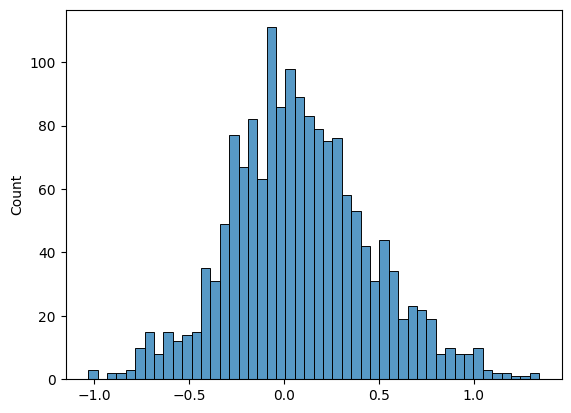

In [11]:
dataset = LmdbDataset({"src": "set_example_train/train.lmdb"})
db = [data['Form'] for data in dataset]
sns.histplot(db, binwidth=0.05)

print(f"{'Mean:':<10}{np.mean(db):.4f}")
print(f"{'Std Dev:':<10}{np.std(db):.4f}")
print(f"{'Min:':<10}{np.min(db):.4f}")
print(f"{'Max:':<10}{np.max(db):.4f}")

### Formation Energy Distribution - Validation Set

The validation set should have a similar distribution to the training set to ensure reliable model evaluation during training.

Mean:     -0.0109
Std Dev:  0.3470
Min:      -0.8184
Max:      1.0048


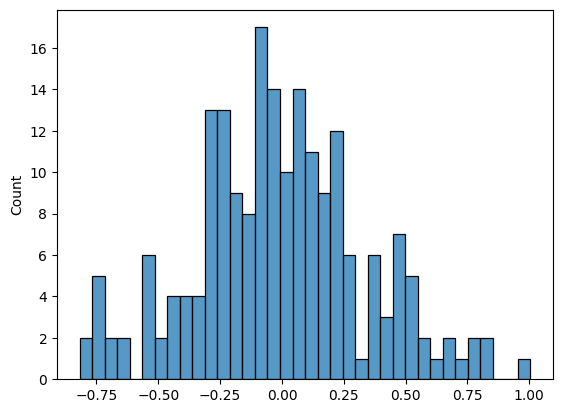

In [12]:
dataset = LmdbDataset({"src": "set_example_train/val.lmdb"})
db = [data['Form'] for data in dataset]
sns.histplot(db, binwidth=0.05)

print(f"{'Mean:':<10}{np.mean(db):.4f}")
print(f"{'Std Dev:':<10}{np.std(db):.4f}")
print(f"{'Min:':<10}{np.min(db):.4f}")
print(f"{'Max:':<10}{np.max(db):.4f}")

### Formation Energy Distribution - Test Set

The test set provides the final evaluation of model performance. Its distribution should also be representative of the overall dataset.

Mean:     0.0497
Std Dev:  0.3989
Min:      -0.9167
Max:      1.2082


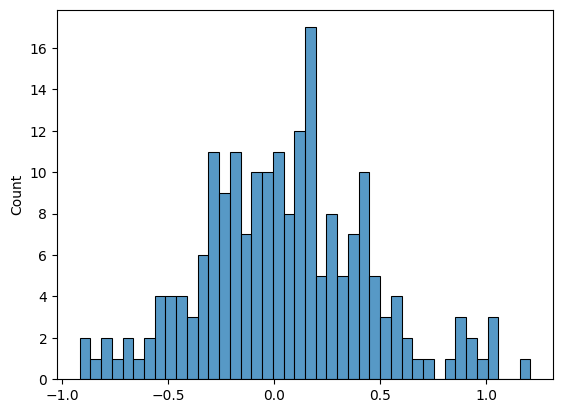

In [13]:
dataset = LmdbDataset({"src": "set_example_train/test.lmdb"})
db = [data['Form'] for data in dataset]
sns.histplot(db, binwidth=0.05)

print(f"{'Mean:':<10}{np.mean(db):.4f}")
print(f"{'Std Dev:':<10}{np.std(db):.4f}")
print(f"{'Min:':<10}{np.min(db):.4f}")
print(f"{'Max:':<10}{np.max(db):.4f}")

# Example 2: Application Dataset

In this section, we prepare a dataset for applying a trained model to new compounds. 
## Key Differences from Training Datasets

- **No target properties**: Application datasets only contain structural information
- **No train/val/test splits**: All data goes into one dataset for inference
- **Different property mapping**: Only identifiers (UUID) are preserved

The process is similar to the training dataset preparation, but simpler since we don't need target properties or data splitting.

### Load Application Dataset

This CSV file contains crystal structures for compounds where we want to predict formation energies using our trained model. Notice that it only contains structural information (cell, positions, numbers) and identifiers, but no target properties.

In [14]:
compounds_df = pd.read_csv('./database_example_apply.csv', index_col=0, )
compounds_df.head(4)

,composition,UUID,cell,positions,numbers
100321,Pt2TiIn,2f2cef54-2430-4ab7-a54e-553fc34f9e2a,"[[2.84816623, 2.84816623, -0.0], [-2.84816623,...","[[0.5, 3.898027484951806e-17, 0.25], [0.999999...",[78 78 78 78 22 22 49 49]
29486,ZrCdGa,cf7fc8f6-d746-4026-b6cd-7c9a84c63210,"[[3.31190509, 3.31190509, 0.0], [-3.31190509, ...","[[0.5, 0.0, 0.25], [0.0, 0.5, 0.75], [0.0, 0.0...",[40 40 48 48 31 31]
15406,Fe2RhTl,60c3bc8c-05e1-40e3-9e31-4e3480ece41f,"[[2.73891086, 2.73891086, 0.0], [-2.73891086, ...","[[0.5, 0.0, 0.25], [0.0, 0.49999999999999983, ...",[26 26 26 26 45 45 81 81]
57985,AuCrSn,2750a717-58c2-4a34-b6fa-08233f3f1258,"[[-0.0, 3.18684657, 3.18684657], [3.18684657, ...","[[0.25, 0.25, 0.25], [0.5, 0.5, 0.5], [0.0, 0....",[79 24 50]


### Create Application LMDB Database

For application datasets, we:
1. Only map the UUID identifier (no target properties)
2. Create a single dataset called 'apply' (no train/val/test split)
3. Convert directly to LMDB format for efficient inference

In [15]:
properties = {
    "UUID": "UUID",
} 
atoms_list = db_to_atomslist(compounds_df, properties=properties)
split_set  = {'apply' : atoms_list}
split_set_to_lmdb(split_set, properties, dir_name='set_example_apply')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1085.48it/s]


# Example 3: Transfer Learning Dataset (Critical Temperature)

This section prepares a dataset for transfer learning example, where we'll use a pre-trained formation energy model or MLIP as the starting point for training a critical temperature (Tc) prediction model.

The process is similar to the formation energy dataset, but with a different target property (Tc instead of formation energy).

### Load Critical Temperature Dataset

This dataset contains the same structural information as before, but with critical temperature (Tc) as the target property instead of formation energy. 

In [16]:
compounds_df = pd.read_csv('./database_example_trainTL.csv', index_col=0, )
compounds_df.head(4)

,composition,UUID,cell,positions,numbers,energy (eV/atom),formation energy (eV/atom),Tc (K)(KKR-FULL)
71463,Mn2IrGa,ca5feb8c-69bd-4a95-82b8-4c4a1b3ac12a,"[[2.71024883, 2.71024883, -0.0], [-2.71024883,...","[[0.5, 0.0, 0.24999999999999997], [0.0, 0.5, 0...",[25 25 25 25 77 77 31 31],-7.753626,-0.385351,983.8
12071,Mn2ZnGe,03fe1854-f790-4966-b611-454926827455,"[[2.69162935, 2.69162935, 0.0], [-2.69162935, ...","[[0.5, 0.0, 0.24999999999999997], [0.0, 0.5, 0...",[25 25 25 25 30 30 32 32],-5.933164,-0.099737,646.8
71572,Mn2PtIn,efbe8195-7fdb-4d6e-967e-350dfa9f0b72,"[[2.88746869, 2.88746869, -0.0], [-2.88746869,...","[[0.5, 0.0, 0.25], [0.0, 0.5, 0.74999999999999...",[25 25 25 25 78 78 49 49],-6.819061,-0.224936,297.4
100642,Pt2CoSn,a68bf9d1-b6c7-48e6-a283-c99a8b4416d1,"[[2.84277649, 2.84277649, -0.0], [-2.84277649,...","[[0.5, 0.0, 0.25], [0.0, 0.5, 0.75000000000000...",[78 78 78 78 27 27 50 50],-5.909162,-0.136272,14.2


### Prepare Transfer Learning Dataset
Here we:
1. Map the UUID identifier and Tc property
2. Split the data into train/validation/test sets using the same 80/10/10 ratio
3. Create LMDB databases for transfer learning training

In [17]:
properties = {
    "UUID": "UUID",
    "Tc": 'Tc (K)(KKR-FULL)'
} 
atoms_list = db_to_atomslist(compounds_df, properties=properties)
split_set = split_dataset(atoms_list, ratio = [0.8, 0.1, 0.1])
split_set_to_lmdb(split_set, properties, dir_name='set_example_trainTL')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 1094.51it/s]
